In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor


In [4]:
housing = fetch_california_housing(as_frame = True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df < lower) | (df > upper)].sum()

print(outliers)

MedInc         6.894680e+03
HouseAge       0.000000e+00
AveRooms       6.602733e+03
AveBedrms      2.494182e+03
Population     5.572878e+06
AveOccup       6.748646e+03
Latitude       0.000000e+00
Longitude      0.000000e+00
MedHouseVal    5.347154e+03
dtype: float64


In [13]:
df = df[~((df<lower) | (df>upper)).any(axis = 1)]
print("Cleaned:",df.shape)

Cleaned: (16312, 9)


In [14]:
x = df.drop('MedHouseVal',axis = 1)
y = df['MedHouseVal']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [25]:
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)

LinearRegression()

In [29]:
y_pred_lr = lr_model.predict(x_test)

In [30]:
lr_mae = mean_absolute_error(y_test,y_pred_lr)
lr_mse = mean_squared_error(y_test,y_pred_lr)
lr_rmse = np.sqrt(mse)
lr_r2 = r2_score(y_test,y_pred_lr)

In [31]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.42355274297359874
MSE : 0.31652227705444813
RMSE: 0.5626031257062549
R²  : 0.6378964374821553


In [46]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs = -1
)

rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [34]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42,
)

gbr.fit(x_train,y_train)

GradientBoostingRegressor(random_state=42)

In [56]:
xgb = XGBRegressor(
    n_estimators=500,
    random_state=42,
    learning_rate = 0.05,
    max_depth = 6
)

xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [57]:
def evaluate_model(name,model,x_test,y_test):
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,y_pred)
    print(f"{name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print("-"*30)

evaluate_model("Linear Regression",lr_model,x_test,y_test)
evaluate_model("Random Forest",rf,x_test,y_test)
evaluate_model("Gradient Boosting",gbr,x_test,y_test)
evaluate_model("XGBoost",xgb,x_test,y_test)


Linear Regression
MAE : 0.42355274297359874
MSE : 0.31652227705444813
RMSE: 0.5626031257062549
R²  : 0.6378964374821553
------------------------------
Random Forest
MAE : 0.2887176714577587
MSE : 0.17661597217930677
RMSE: 0.4202570310884837
R²  : 0.7979501685668768
------------------------------
Gradient Boosting
MAE : 0.3227122538618526
MSE : 0.204946496128729
RMSE: 0.4527101679095898
R²  : 0.7655398632147572
------------------------------
XGBoost
MAE : 0.25858720808441277
MSE : 0.14066094517447084
RMSE: 0.37504792383703556
R²  : 0.8390829554595884
------------------------------


In [43]:
lr_model.score(x_test,y_test)

0.6378964374821553

In [58]:
print(rf.score(x_test,y_test))
print(gbr.score(x_test,y_test))
print(xgb.score(x_test,y_test))

0.7979501685668768
0.7655398632147572
0.8390829554595884


In [59]:
print(rf.score(x_train,y_train))
print(gbr.score(x_train,y_train))
print(xgb.score(x_train,y_train))

0.9704609272150262
0.7828266781101718
0.9330975346856673


In [60]:
scores = cross_val_score(
    xgb,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print("Mean CV R²:", scores.mean())

[0.82356228 0.82567106 0.81054018 0.81312829 0.82622904]
Mean CV R²: 0.819826169239555


In [61]:
train_pred = xgb.predict(x_train)
test_pred = xgb.predict(x_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))

Train RMSE: 0.24468863123330012
Test RMSE : 0.37504792383703556
Train R²: 0.9330975346856673
Test R² : 0.8390829554595884


In [62]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
train_pred = xgb.predict(x_train)
test_pred = xgb.predict(x_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))

Train RMSE: 0.39565165146680775
Test RMSE : 0.41301003090086763
Train R²: 0.8250795829621503
Test R² : 0.8048584656216294


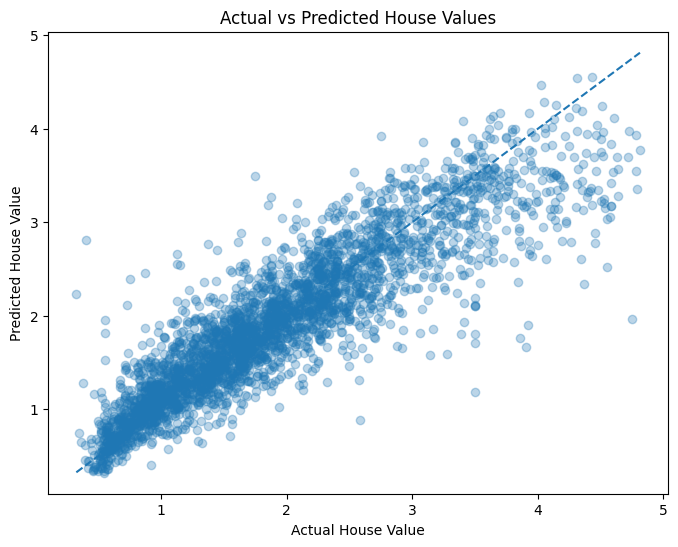

In [66]:
y_pred = xgb.predict(x_test)


plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()